In [ ]:
import warnings
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# OD Matrix and MapTrix Visualizations

Demo of `ODMatrixVisualizer` and `MapTrixVisualizer` using Shenzhen taxi flow data.

**Prerequisites:**
- `geoflowkit` installed (`pip install -e .`)
- Data files in `examples/data/sz_data/`

## Setup

Import libraries and configure matplotlib.

In [ ]:
from geoflowkit import read_csv
from geoflowkit.visualization.maptrix import MapTrixVisualizer
from geoflowkit.visualization.od_matrix import ODMatrixVisualizer

In [ ]:
plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['mathtext.fontset'] = 'stix'

warnings.filterwarnings(
    'ignore', message='Geometry is in a geographic CRS',
)

## 1. Load and prepare data

Read the Shenzhen taxi flow CSV, sample 5000 flows, and clip to the city border.

In [ ]:
DATA_DIR = 'examples/data/sz_data'

fdf = read_csv(
    f'{DATA_DIR}/sz_taxi_flow.csv',
    use_cols=['ox', 'oy', 'dx', 'dy'],
    crs='EPSG:4326',
)
print(f'Loaded {len(fdf):,} flows')

In [ ]:
N = 5000
np.random.seed(42)
indices = np.random.choice(len(fdf), size=N, replace=False)
fdf_sample = fdf.iloc[indices].reset_index(drop=True)
print(f'Using {len(fdf_sample):,} flows for visualization')

In [ ]:
border = gpd.read_file(f'{DATA_DIR}/sz_border.gpkg')
print(f'Loaded {len(border)} districts: {border["Name"].tolist()}')

In [ ]:
shenzhen_union = border.union_all()
fdf_sample = fdf_sample.clip(shenzhen_union)
print(f'After clipping to border: {len(fdf_sample)} flows remain')

## 2. OD Matrix — basic heatmap

Aggregate flows by origin/destination zone and plot a heatmap where colour = flow count.

In [ ]:
fig1, ax1 = plt.subplots(figsize=(10, 8))
ODMatrixVisualizer(
    origin_zones=border,
    zone_id_col='Name',
    weight='count',
    cmap='OrRd',
    show_labels=True,
    label_fontsize=9,
).fit_plot(fdf_sample, ax=ax1, colorbar=True)
ax1.set_title(
    'OD Matrix — Shenzhen Taxi Flows (by district, colour = count)',
    fontsize=14, weight='bold', pad=12,
)
fig1.tight_layout()
plt.show()

## 3. OD Matrix — bubble matrix

Colour still represents flow count, but circle size is proportional to **total flow length**.

In [ ]:
fig2, ax2 = plt.subplots(figsize=(10, 8))
ODMatrixVisualizer(
    origin_zones=border,
    zone_id_col='Name',
    weight='count',
    size_weight='length',
    cmap='OrRd',
    show_labels=True,
    label_fontsize=9,
).fit_plot(fdf_sample, ax=ax2, colorbar=True)
ax2.set_title(
    'OD Matrix Bubble — colour=count, circle size=flow length',
    fontsize=14, weight='bold', pad=12,
)
fig2.tight_layout()
plt.show()

## 4. MapTrix — rotated matrix + maps

Combines an OD matrix rotated 45° with inflow/outflow maps on the sides. Circle size represents flow length.

In [ ]:
fig3 = MapTrixVisualizer(
    origin_zones=border,
    zone_id_col='Name',
    weight='count',
    size_weight='length',
    matrix_cmap='OrRd',
    line_color='black',
    line_alpha=0.5,
    show_labels=True,
    label_fontsize=9,
    out_title='Outflow',
    in_title='Inflow',
    title_fontsize=16,
    include_self_flows=False,
).fit_plot(fdf_sample, figsize=(16, 9))
plt.show()

# FTSNE Dimensionality Reduction

Flow-based t-SNE (FTSNE) visualizations using simulated and real-world flow datasets.

In [2]:
import geoflowkit as gfk
from geoflowkit import FTSNE

In [4]:
def constrained_layout(ax, x, y, eps=0.03):
    min_x, max_x = min(x), max(x)
    x_eps = eps * (max_x - min_x)
    min_y, max_y = min(y), max(y)
    y_eps = eps * (max_y - min_y)
    ax.set_xlim(min_x - x_eps, max_x + x_eps)
    ax.set_ylim(min_y - y_eps, max_y + y_eps)

In [5]:
def get_color_map(flow_types):
    colors = [
        'black',      # 黑色
        'red',        # 红色
        'blue',       # 蓝色
        'green',      # 绿色
        'gold',       # 金色
        'magenta',    # 洋红色
        'cyan',       # 青色
        'purple',     # 紫色
        'brown',      # 棕色
        'pink',       # 粉色
    ]
    color_map = {'random': 'gray'}
    num = 0
    for flow_type in flow_types:
        if flow_type=='random':
            continue
        if num>=len(colors):
            color_map[flow_type] = 'white'
        else:
            color_map[flow_type] = colors[num]
        num += 1
    return color_map

def map_flow_color(flow_types):
    if isinstance(flow_types, pd.Series):
        unique_flow_types = flow_types.unique()
    elif isinstance(flow_types, np.ndarray):
        unique_flow_types = np.unique(flow_types)
    else:
        flow_types = np.array(flow_types)
        unique_flow_types = np.unique(flow_types)
    unique_flow_types = np.sort(unique_flow_types)
    color_map = get_color_map(unique_flow_types)
    colors = [color_map[flow_type] for flow_type in flow_types]

    return colors

## Simulated dataset 1 visualisation

In [6]:
path = './data/sys_flow/sys_flow_dataset1.gpkg'
layers = ['RP', 'CP', 'CvP', 'DvP']
fdfs = []
for i, layer in enumerate(layers):
    if i==0:
        fdf = gfk.read_file(path, layer=layer)
    elif i==1:
        fdf = gfk.read_file(path, layer=layer)
    else:
        fdf = gfk.read_file(path, layer=layer)
    fdfs.append(fdf)
    print(fdf.shape)

(1000, 8)
(137, 8)
(180, 8)
(200, 8)


### Global interpretability

In [7]:
X_embeddeds1 = []
perplexitys = [200, 80, 80, 80]
for i, gfd in enumerate(fdfs[:4]):
    transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                        perplexity=perplexitys[i], log_progress='notebook', 
                        early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
    X_embedded = transformer.fit_transform(fdfs[i], identity={'o': 0, 'd': 1})
    X_embeddeds1.append(X_embedded)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

### Local interpretability

In [13]:
X_embeddeds2 = []
perplexitys = [100, 80, 80, 80]
for i, gfd in enumerate(fdfs[:4]):
    transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                        perplexity=perplexitys[i], log_progress='notebook', 
                        early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
    X_embedded = transformer.fit_transform(fdfs[i], intersection={('o', 'd'): (0, 1)})
    X_embeddeds2.append(X_embedded)

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

  0%|          | 0/100 [00:00<?, ?it/s]

### Plotting

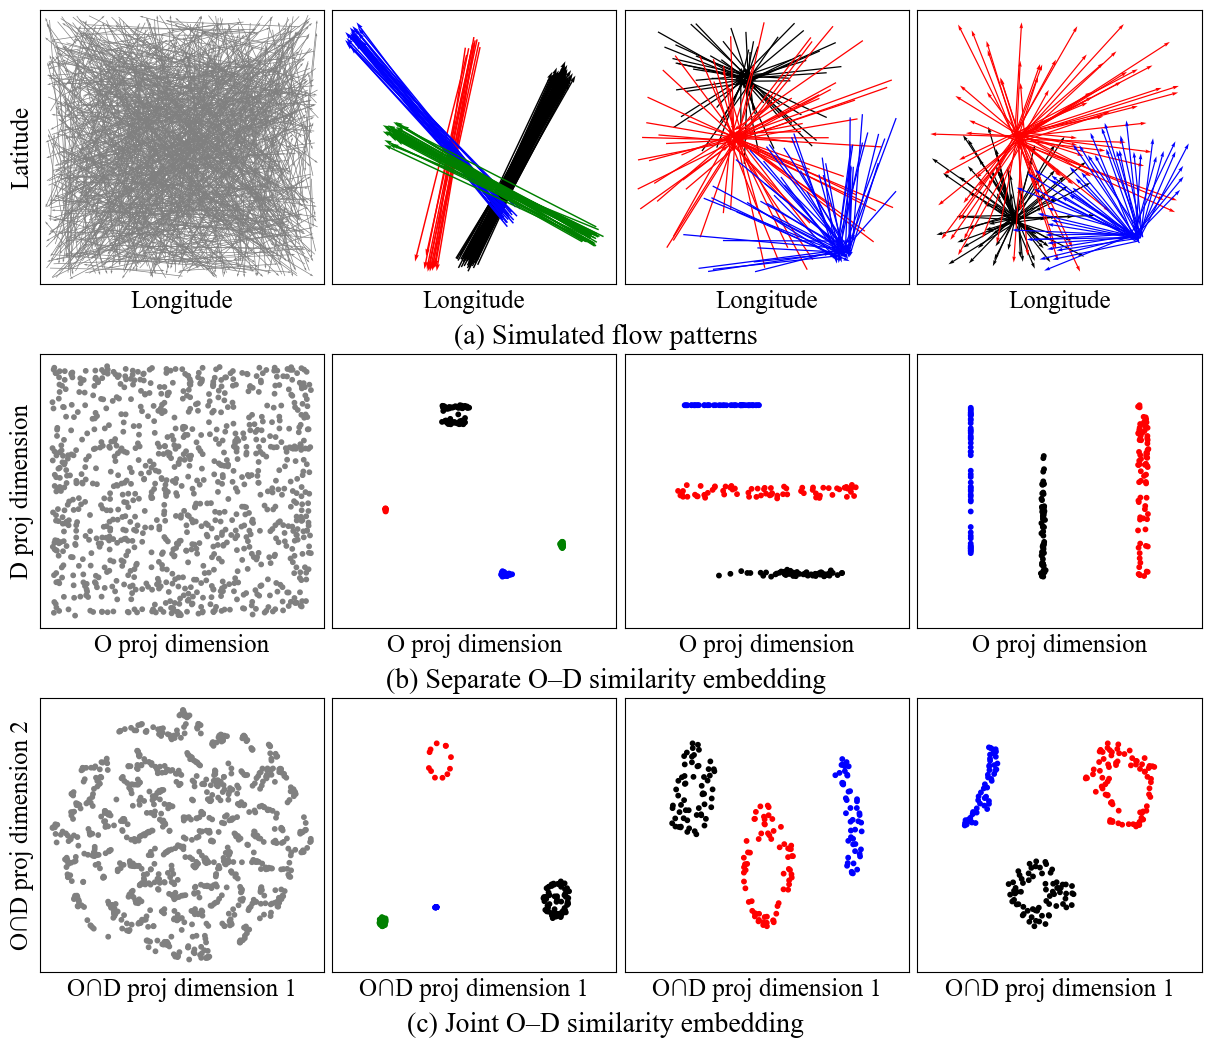

In [ ]:
# 创建一个整体为 3x4 网格的画布
fig = plt.figure(figsize=(12, 10), constrained_layout=True)

# 使用 GridSpec 创建一个 3x4 的网格
gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.12)

label_fontsize, text_fontsize = 18, 20
for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[0, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    if i>0:
        fdf.plot(ax=ax, color=flow_colors, zoom=0.05)
    else:
        fdf.plot(ax=ax, color=flow_colors, zoom=0.02)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('Longitude', fontsize=label_fontsize)
    if i==0:
        ax.set_ylabel('Latitude', fontsize=label_fontsize)

for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[1, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    ax.scatter(X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], c=flow_colors, s=10)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('O proj dimension', fontsize=label_fontsize)
    if i == 0:
        ax.set_ylabel('D proj dimension', fontsize=label_fontsize)
    if i>0:
        constrained_layout(ax, X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], eps=0.3)
    else:
        constrained_layout(ax, X_embeddeds1[i][:, 0], X_embeddeds1[i][:, 1], eps=0.05)

for i, fdf in enumerate(fdfs[:4]):
    ax = fig.add_subplot(gs[2, i])
    flow_colors = map_flow_color(fdfs[i]['flow_type'])
    ax.scatter(X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], c=flow_colors, s=10)
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])
    ax.set_xlabel('O∩D proj dimension 1', fontsize=label_fontsize)
    if i==0:
        ax.set_ylabel('O∩D proj dimension 2', fontsize=label_fontsize)
    if i>0:
        constrained_layout(ax, X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], eps=0.25)
    else:
        constrained_layout(ax, X_embeddeds2[i][:, 0], X_embeddeds2[i][:, 1], eps=0.05)


# ----- 行标题（下方） -----
# 1. 强制计算布局
fig.canvas.draw()

titles = [
    '(a) Simulated flow patterns',
    '(b) Separate O–D similarity embedding',
    '(c) Joint O–D similarity embedding'
]

# 偏移量：标题位于子图底部下方 0.015 倍画布高度处（可微调）
offset = 0.04

for row_idx, title in enumerate(titles):
    # 选取每行第二列子图作为水平参考
    ax = fig.axes[row_idx * 4 + 1]
    bbox = ax.get_position()               # 子图在 figure 中的位置
    # x_center = bbox.x0 + bbox.width / 2    # 水平居中
    y_bottom = bbox.y0 - offset            # 子图底部稍微下移

    fig.text(0.5, y_bottom, title,
             ha='center', va='top', fontsize=text_fontsize)

In [ ]:
# fig.savefig('./spatial_pattern_ftsne.png', dpi=300, bbox_inches='tight')

## Spatial temporal dataset visualization

In [74]:
from geoflowkit import FlowDataFrame
from geoflowkit.io import flows_from_od

In [116]:
import numpy as np

def generate_od_cluster(mean_origin, std_origin,
                        mean_dest, std_dest,
                        size, time_offset=0.0, time_noise=0.0):
    """
    在三维空间 (x, y, t) 中用独立高斯生成起点和终点。
    
    参数
    ----------
    mean_origin, std_origin : 起点的三维均值和标准差（可传入列表 [x, y, t]）
    mean_dest,   std_dest   : 终点的三维均值和标准差
    size : 流数量
    time_offset : 若 >0，则终点时间 = 起点时间 + time_offset + 噪声
    time_noise  : 配合 time_offset 时额外的时间噪声标准差
    
    返回
    ----------
    origins_xy  : (size, 2) 起点空间坐标
    origins_t   : (size,)   起点时间
    dests_xy    : (size, 2) 终点空间坐标
    dests_t     : (size,)   终点时间
    """
    # 生成起点三维点
    origin = np.random.normal(loc=mean_origin, scale=std_origin, size=(size, 3))
    origins_xy = origin[:, :2]
    origins_t  = origin[:, 2]

    # 生成终点空间坐标（二维）
    dest_xy = np.random.normal(loc=mean_dest[:2], scale=std_dest[:2], size=(size, 2))

    # 终点时间处理
    if time_offset > 0:
        # 保留原有逻辑：d_t = o_t + 偏移 + 噪声
        dest_t = origins_t + time_offset + np.random.normal(0, time_noise, size)
    else:
        # 完全独立的三维高斯生成终点时间
        dest_t = np.random.normal(loc=mean_dest[2], scale=std_dest[2], size=size)

    return origins_xy, origins_t, dest_xy, dest_t

In [198]:
np.random.seed(42)

# 聚类1: 起点在 (0.3, 0.2, 0.15) 附近，终点在 (0.7, 0.7) 附近，时间增加 0.15
cluster1_o, cluster1_o_t, cluster1_d, cluster1_d_t = generate_od_cluster(
    mean_origin=[0.3, 0.2, 0.15], std_origin=[0.03, 0.03, 0.01],
    mean_dest=[0.8, 0.8, 0.0],   std_dest=[0.03, 0.03, 0.0],
    size=80, time_offset=0.15, time_noise=0.02
)

# 聚类2: 起点在 (0.2, 0.2, 0.45)，终点在 (0.85, 0.2)，时间增加 0.2
cluster2_o, cluster2_o_t, cluster2_d, cluster2_d_t = generate_od_cluster(
    mean_origin=[0.2, 0.8, 0.45], std_origin=[0.03, 0.03, 0.01],
    mean_dest=[0.85, 0.1, 0.0],   std_dest=[0.03, 0.03, 0.0],
    size=80, time_offset=0.2, time_noise=0.02
)

# 聚类3: 起点在 (0.3, 0.2, 0.70)，终点在 (0.7, 0.7)，时间增加 0.2
cluster3_o, cluster3_o_t, cluster3_d, cluster3_d_t = generate_od_cluster(
    mean_origin=[0.3, 0.2, 0.70], std_origin=[0.03, 0.03, 0.01],
    mean_dest=[0.8, 0.8, 0.0],    std_dest=[0.03, 0.03, 0.0],
    size=80, time_offset=0.2, time_noise=0.02
)

# 随机流：确保终点时间 > 起点时间
n_random = 200
random_o = np.random.uniform(0, 1, (n_random, 2))
random_d = np.random.uniform(0, 1, (n_random, 2))

# 起点时间在 [0, 0.9] 之间，留出至少 0.1 的增量空间，避免终点超出 1
random_o_t = np.random.uniform(0, 0.9, n_random)
# 时间增量均匀分布，保证终点时间在 (o_t, 1] 之间
delta_t = np.random.uniform(0.01, 1 - random_o_t)  # 最小增量 0.01 避免完全相等
random_d_t = random_o_t + delta_t

In [273]:
fdf = pd.concat([
    FlowDataFrame(
        np.column_stack([
            cluster1_o_t, cluster1_d_t, 
            ['cluster1']*cluster1_o_t.size,
            ['red']*cluster1_o_t.size,
        ]),
        geometry=flows_from_od(cluster1_o, cluster1_d),
        columns=['ot', 'dt', 'flow_type', 'color']
    ),
    FlowDataFrame(
        np.column_stack([
            cluster2_o_t, cluster2_d_t, 
            ['cluster2']*cluster2_o_t.size,
            ['blue']*cluster2_o_t.size,
        ]),
        geometry=flows_from_od(cluster2_o, cluster2_d),
        columns=['ot', 'dt', 'flow_type', 'color']
    ),
    FlowDataFrame(
        np.column_stack([
            cluster3_o_t, cluster3_d_t, 
            ['cluster3']*cluster3_d_t.size,
            ['green']*cluster3_d_t.size,
        ]),
        geometry=flows_from_od(cluster3_o, cluster3_d),
        columns=['ot', 'dt', 'flow_type', 'color']
    ),
    FlowDataFrame(
        np.column_stack([
            random_o_t, random_d_t, 
            ['random']*random_o_t.size,
            ['grey']*random_o_t.size,
        ]),
        geometry=flows_from_od(random_o, random_d),
        columns=['ot', 'dt', 'flow_type', 'color']
    )
])
fdf

,ot,dt,flow_type,color,geometry
0,0.15647688538100693,0.2745883322051196,cluster1,red,"FLOW (0.314901424590337 0.19585207096486448, 0..."
1,0.1476586304305082,0.28567112997143274,cluster1,red,"FLOW (0.34569089569224076 0.19297539875829994,..."
2,0.14530525614065049,0.29541013013501416,cluster1,red,"FLOW (0.34737638446522173 0.22302304187458727,..."
3,0.14534270246429742,0.29628231433959223,cluster1,red,"FLOW (0.3162768013075789 0.18609746921562614, ..."
4,0.13275082167486968,0.27374951224528477,cluster1,red,"FLOW (0.307258868146981 0.14260159266026606, 0..."
...,...,...,...,...,...
195,0.4553621169614385,0.9831788656252858,random,grey,"FLOW (0.0938572848233562 0.9096268194365924, 0..."
196,0.19876750466670803,0.6863848731413053,random,grey,"FLOW (0.6692002629380784 0.8292867993167555, 0..."
197,0.03503696699310071,0.11854951234071562,random,grey,"FLOW (0.8789789002822673 0.5717723520483222, 0..."
198,0.03241693646228375,0.11479452496991299,random,grey,"FLOW (0.5174463517550413 0.4304274103209902, 0..."


In [216]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=150, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, intersection={('o', 'ot'): 0, ('d', 'dt'): 1}, relation='probability')
flow_colors = map_flow_color(fdf['flow_type'])

  0%|          | 0/100 [00:00<?, ?it/s]

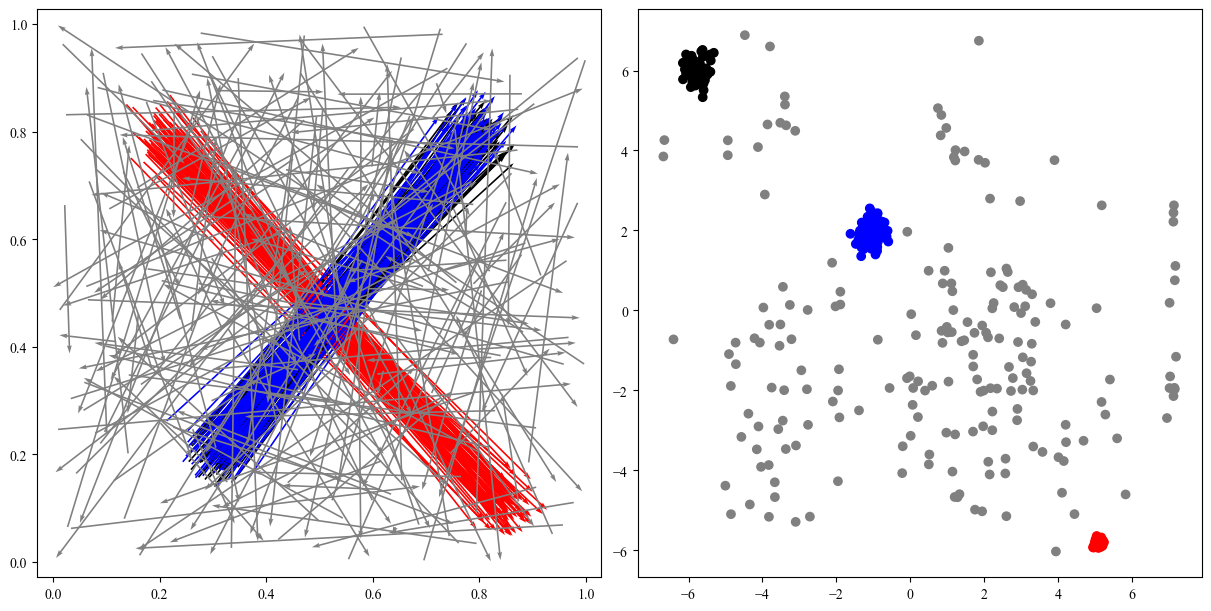

In [217]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

In [209]:
def plot_3d_flows(ax, o, o_t, d, d_t, color, label, alpha=0.7, linewidth=1.2):
    """
    绘制3D带箭头的OD流
    o: 起点空间坐标 (N, 2)
    o_t: 起点时间 (N,)
    d: 终点空间坐标 (N, 2)
    d_t: 终点时间 (N,)
    """
    # 提取起点 X, Y, Z(时间)
    X = o[:, 0]
    Y = o[:, 1]
    Z = o_t
    
    # 计算向量长度 (终点 - 起点)
    U = d[:, 0] - o[:, 0]
    V = d[:, 1] - o[:, 1]
    W = d_t - o_t
    
    # 使用 quiver 绘制带箭头的线段
    ax.quiver(X, Y, Z, U, V, W, 
              color=color, alpha=alpha, 
              arrow_length_ratio=0.05, # 箭头大小占整体线段的比例
              linewidth=linewidth)
    
    # 为了在图例(legend)中显示颜色，添加一个空线段
    ax.plot([], [], [], color=color, label=label)

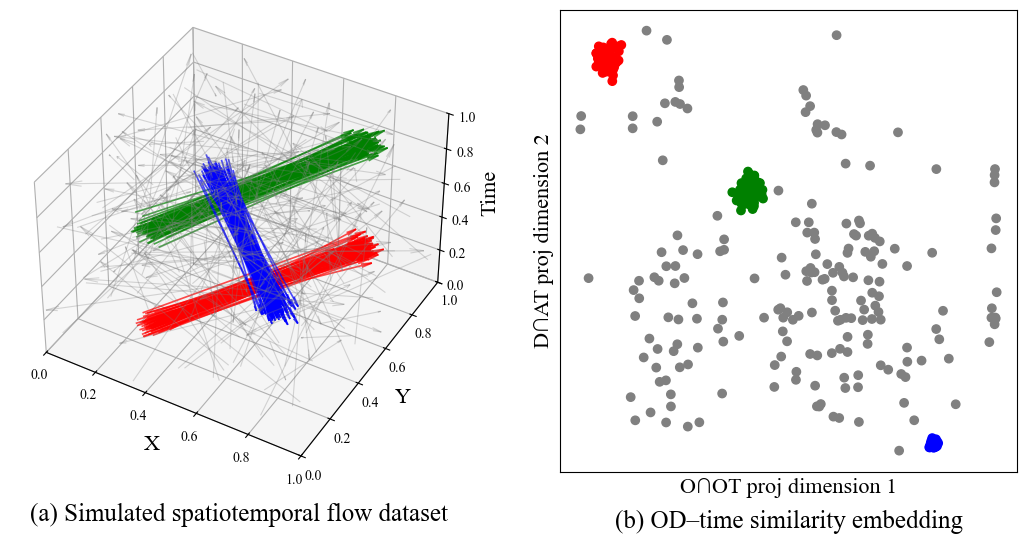

In [274]:
# 创建一个整体为 2x2 网格的画布
fig = plt.figure(figsize=(13, 6))

# 使用 GridSpec 创建一个 4x6 的网格
gs = gridspec.GridSpec(1, 2, figure=fig)
ax1 = fig.add_subplot(gs[0, 0], projection='3d')

# 绘制三个簇
plot_3d_flows(ax1, cluster1_o, cluster1_o_t, cluster1_d, cluster1_d_t, color='red', label='Cluster 1')
plot_3d_flows(ax1, cluster2_o, cluster2_o_t, cluster2_d, cluster2_d_t, color='blue', label='Cluster 2')
plot_3d_flows(ax1, cluster3_o, cluster3_o_t, cluster3_d, cluster3_d_t, color='green', label='Cluster 3')

# 绘制随机流 (使用较低的不透明度和较细的线宽，避免遮挡主要簇的信息)
plot_3d_flows(ax1, random_o, random_o_t, random_d, random_d_t, color='gray', label='Random Flows', alpha=0.3, linewidth=0.8)

# 设置坐标轴标签
ax1.set_xlabel('X', fontsize=16, labelpad=0)
ax1.set_ylabel('Y', fontsize=16, labelpad=0)
ax1.tick_params(pad=0, labelsize=10)
ax1.set_zlabel('Time', fontsize=16, rotation=90, labelpad=0)

# 设置坐标轴范围 (因为高斯分布可能会产生略微超出 [0, 1] 的点，我们留出一点余地)
ax1.set_xlim(0, 1.); ax1.set_ylim(0, 1.); ax1.set_zlim(0, 1.)
# 调整初始视角，使其更容易观察三维结构 [elevation, azimuth]
ax1.view_init(elev=40, azim=-60)
ax1.set_title('(a) Simulated spatiotemporal flow dataset', y=-0.14, fontsize=18)


ax2 = fig.add_subplot(gs[0, 1])
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=fdf['color'].values)
ax2.axes.xaxis.set_ticks([])
ax2.axes.yaxis.set_ticks([])
ax2.set_xlabel('O∩OT proj dimension 1', fontsize=16)
ax2.set_ylabel('D∩AT proj dimension 2', fontsize=16)
ax2.set_title('(b) OD–time similarity embedding', y=-0.14, fontsize=18);

In [276]:
fig.savefig('./spatiatemporal_ftsne.png', dpi=300, bbox_inches='tight')

In [201]:
transformer = FTSNE(learning_rate='auto', max_iter=300, init='random', 
                    perplexity=150, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, intersection={('o', 'd', 'ot', 'dt'): (0, 1)}, relation='probability')

  0%|          | 0/300 [00:00<?, ?it/s]

In [202]:
flow_colors = map_flow_color(fdf['flow_type'])

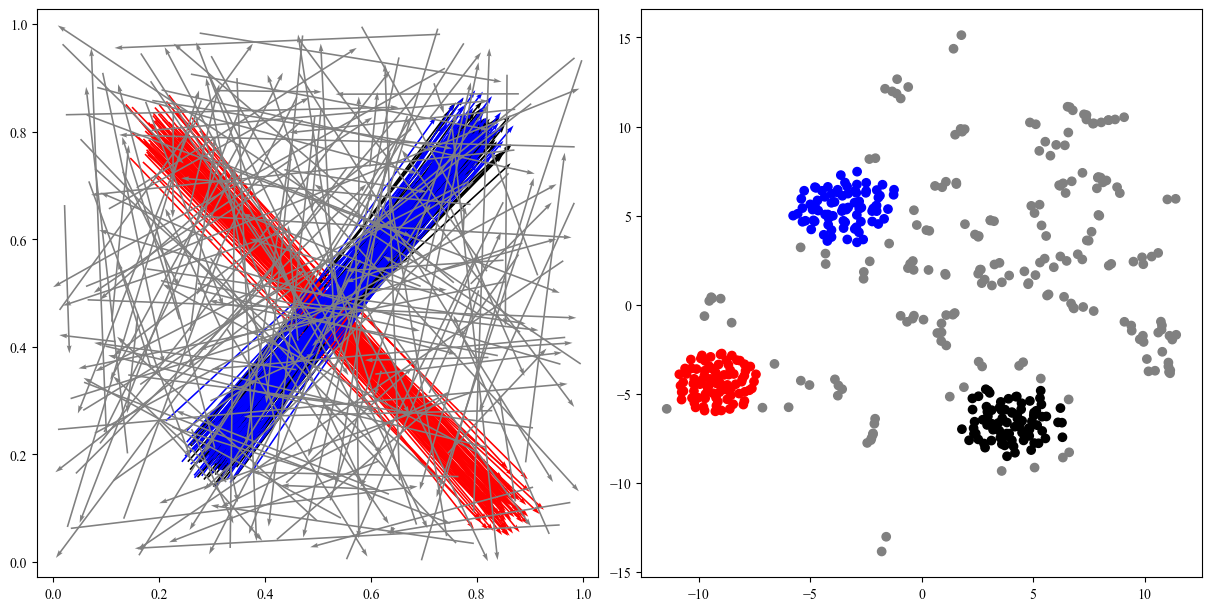

In [203]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

## Simulated dataset 2 visualisation

In [130]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset2.gpkg')
flow_colors = map_flow_color(fdf['flow_type'])

In [33]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

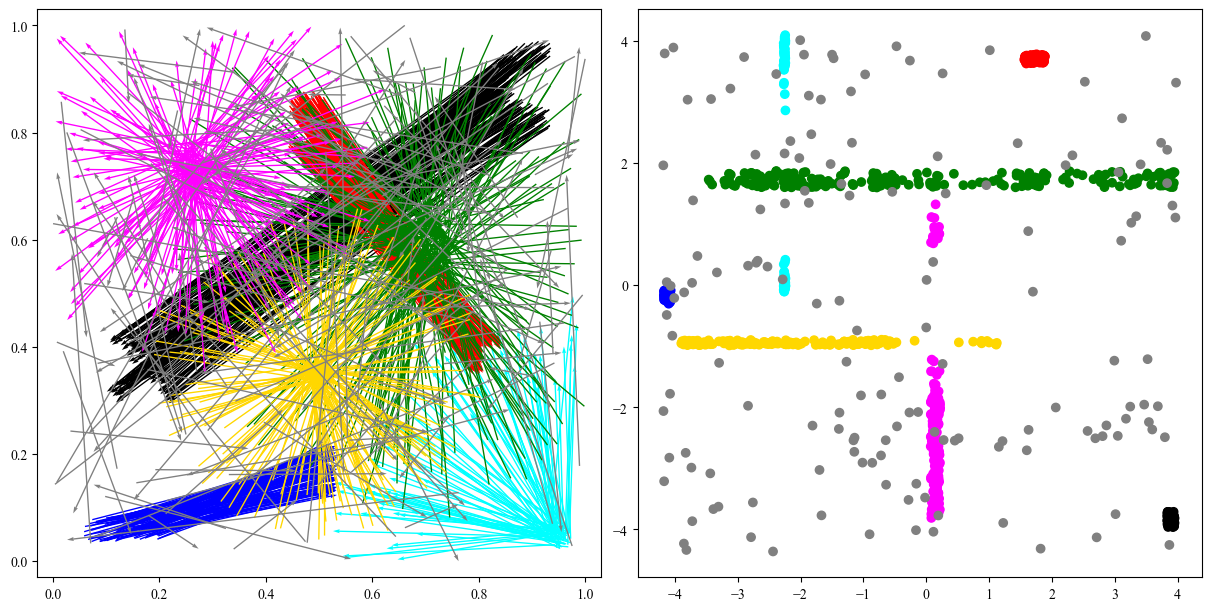

In [34]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

In [35]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=200, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, union={('o', 'd'): (0, 1)}, relation='distance')

  0%|          | 0/100 [00:00<?, ?it/s]

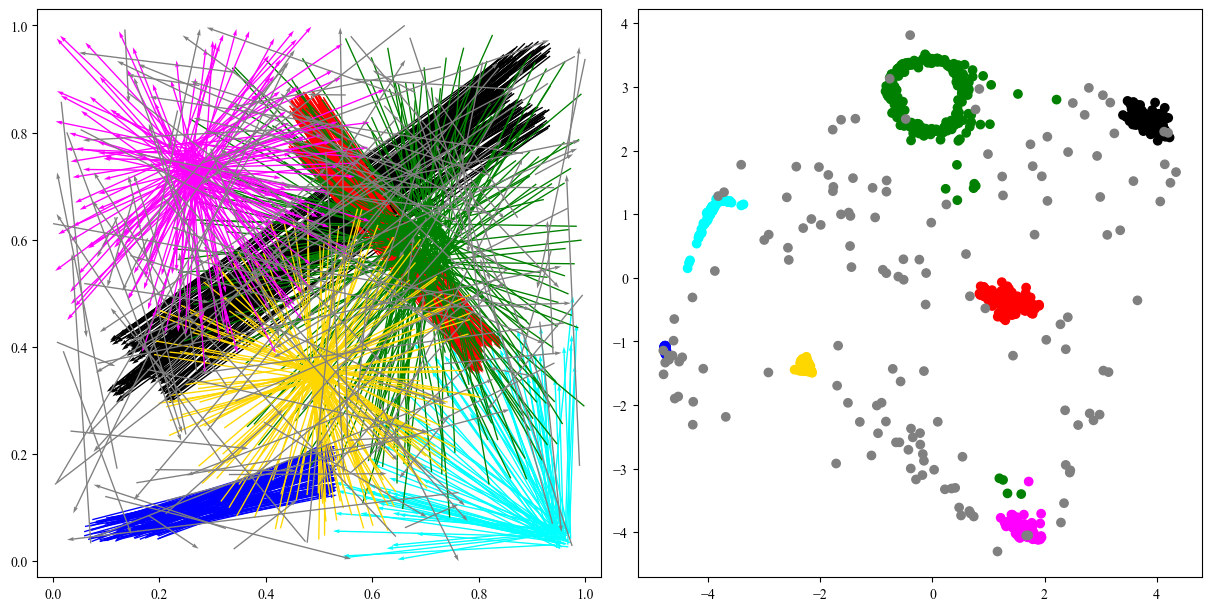

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6), constrained_layout=True)
fdf.plot(ax=ax1, color=flow_colors)
ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=flow_colors);

## Simulated dataset 3 visualisation

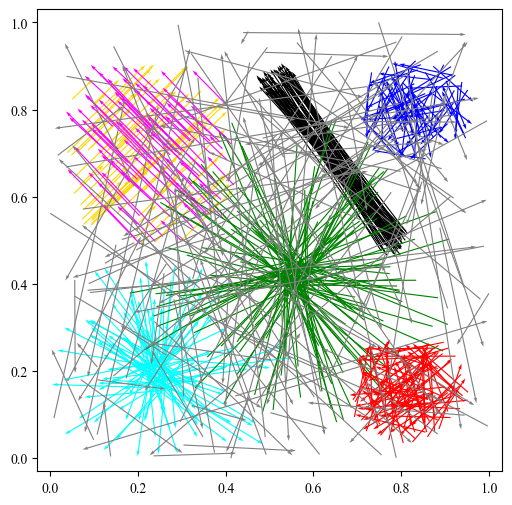

In [37]:
fdf = gfk.read_file('./data/sys_flow/sys_flow_dataset3.gpkg')
flow_colors = np.array(map_flow_color(fdf['flow_type']))
fdf.plot(figsize=(6, 6), color=flow_colors);

In [38]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=200, log_progress='notebook', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded = transformer.fit_transform(fdf, identity={'length': 1, 'angle': 2}, union={('o', 'd'): 0})

  0%|          | 0/100 [00:00<?, ?it/s]

In [39]:
oxs, oys = fdf[['ox', 'oy']].values[:, :2].T
delta_xs = fdf['dx'].values - fdf['ox'].values
delta_ys = fdf['dy'].values - fdf['oy'].values

In [40]:
type_label = {'random': 'RP cluster', 'cluster1': 'CP cluster', 'gather1': 'CvP cluster', 'scatter1': 'DvP cluster', 
    'parallel1': 'PP cluster1', 'parallel2': 'PP cluster2', 'equilong1': 'EP cluster1', 'equilong2': 'EP cluster2'}

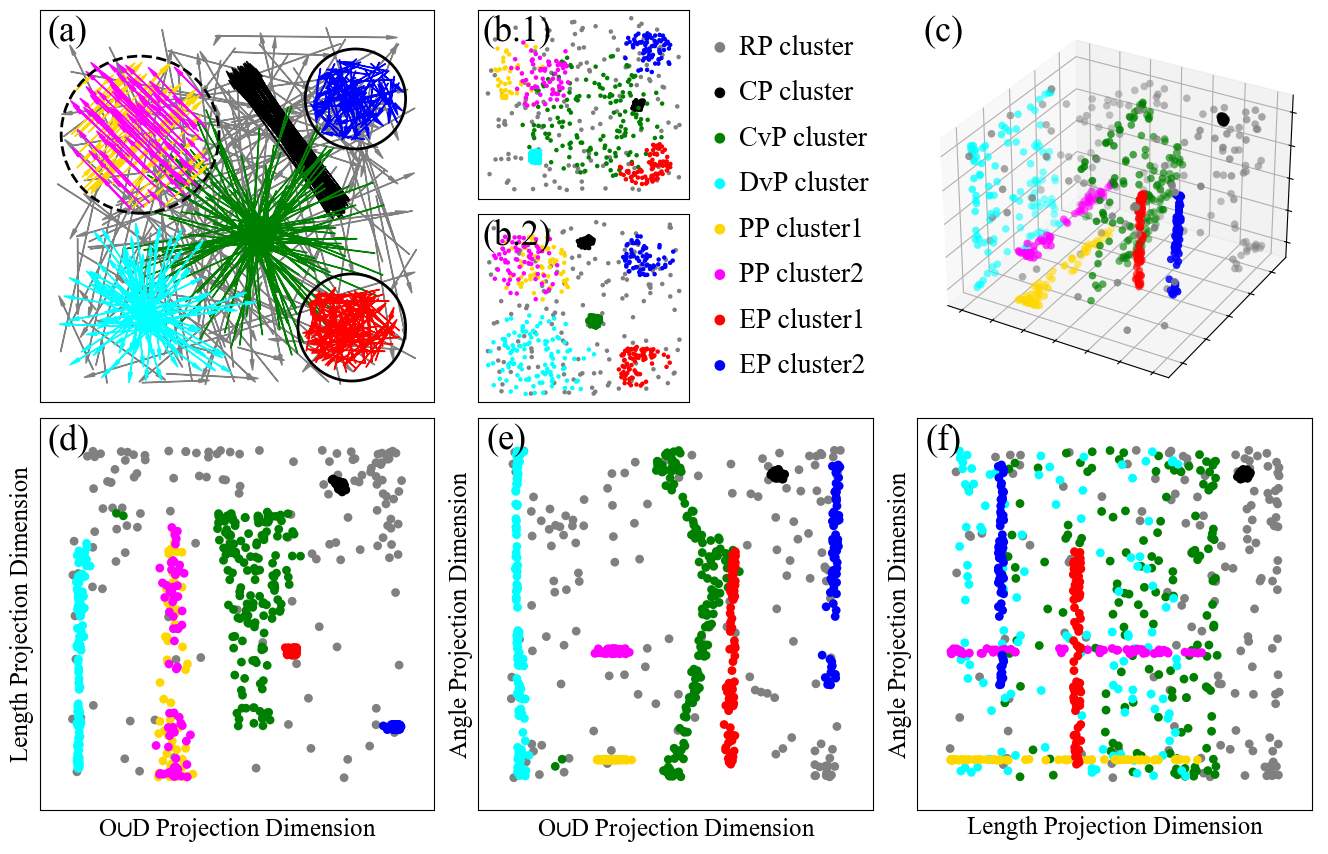

In [41]:
# 创建一个整体为 2x2 网格的画布
fig = plt.figure(figsize=(13, 10.4))

# 使用 GridSpec 创建一个 4x6 的网格
gs = gridspec.GridSpec(4, 6, figure=fig, width_ratios=[1, 1, 1.2, 0.8, 1, 1])

label_fontsize = 18
text_fontsize = 26
ax_flow = fig.add_subplot(gs[:2, :2])
ax_flow.text(0.02, 0.92, f'(a)', fontsize=text_fontsize, transform=ax_flow.transAxes)
ax_small1 = fig.add_subplot(gs[:1, 2])
ax_small1.text(0.02, 0.84, f'(b.1)', fontsize=text_fontsize, transform=ax_small1.transAxes)
ax_small2 = fig.add_subplot(gs[1:2, 2])
ax_small2.text(0.02, 0.84, f'(b.2)', fontsize=text_fontsize, transform=ax_small2.transAxes)

ax_emb1 = fig.add_subplot(gs[2:, :2])
ax_emb1.text(0.02, 0.92, f'(d)', fontsize=text_fontsize, transform=ax_emb1.transAxes)
ax_emb1.set_xlabel(r'O' +r'$\cup$' 'D Projection Dimension', fontsize=label_fontsize)
ax_emb1.set_ylabel('Length Projection Dimension', fontsize=label_fontsize)
ax_emb2 = fig.add_subplot(gs[2:, 2:4])
ax_emb2.text(0.02, 0.92, f'(e)', fontsize=text_fontsize, transform=ax_emb2.transAxes)
ax_emb2.set_xlabel(r'O' +r'$\cup$' 'D Projection Dimension', fontsize=label_fontsize)
ax_emb2.set_ylabel('Angle Projection Dimension', fontsize=label_fontsize)
ax_emb3 = fig.add_subplot(gs[2:, 4:6])
ax_emb3.text(0.02, 0.92, f'(f)', fontsize=text_fontsize, transform=ax_emb3.transAxes)
ax_emb3.set_xlabel('Length Projection Dimension', fontsize=label_fontsize)
ax_emb3.set_ylabel('Angle Projection Dimension', fontsize=label_fontsize)

handles = []
for fp in type_label.keys():
    mask = fdf['flow_type'].values == fp
    label = type_label[fp]
    for ox, oy, delta_x, delta_y, color in zip(oxs[mask], oys[mask], delta_xs[mask], delta_ys[mask], flow_colors[mask]):
        ax_flow.arrow(ox, oy, delta_x, delta_y, head_width=0.01, head_length=0.03, 
                      fc=color, ec=color, length_includes_head=True, alpha=1)
    ax_small1.scatter(fdf['ox'].values[mask], fdf['oy'].values[mask], c=flow_colors[mask], s=5)
    scatter = ax_small2.scatter(fdf['dx'].values[mask], fdf['dy'].values[mask], c=flow_colors[mask], s=5, label=label)
    ax_emb1.scatter(X_embedded[mask, 0], X_embedded[mask, 1], c=flow_colors[mask], s=40, edgecolors='none')
    ax_emb2.scatter(X_embedded[mask, 0], X_embedded[mask, 2], c=flow_colors[mask], s=40, edgecolors='none')
    ax_emb3.scatter(X_embedded[mask, 1], X_embedded[mask, 2], c=flow_colors[mask], s=40, edgecolors='none')
    handles.append(scatter)
constrained_layout(ax_emb1, X_embedded[:, 0], X_embedded[:, 1], 0.1)
constrained_layout(ax_emb2, X_embedded[:, 0], X_embedded[:, 2], 0.1)
constrained_layout(ax_emb3, X_embedded[:, 1], X_embedded[:, 2], 0.1)
circle =plt.Circle((0.23, 0.7), 0.22, edgecolor='black', linestyle='--', fill=False, linewidth=2)
ax_flow.add_patch(circle)
circle =plt.Circle((0.82, 0.16), 0.15, edgecolor='black', linestyle='-', fill=False, linewidth=2)
ax_flow.add_patch(circle)
circle =plt.Circle((0.83, 0.8), 0.14, edgecolor='black', linestyle='-', fill=False, linewidth=2)
ax_flow.add_patch(circle)

ax_emb3d = fig.add_subplot(gs[:2, 4:], projection='3d')
fig.text(0.68, 0.85, '(c)', fontsize=text_fontsize)
ax_emb3d.scatter(X_embedded[:, 0], X_embedded[:, 1], X_embedded[:, 2], c=flow_colors, s=30, edgecolors='none')
ax_emb3d.axes.xaxis.set_ticklabels([])
ax_emb3d.axes.yaxis.set_ticklabels([])
ax_emb3d.axes.zaxis.set_ticklabels([])

for ax in [ax_flow, ax_small1, ax_small2, ax_emb1, ax_emb2, ax_emb3]:
    ax.axes.xaxis.set_ticks([])
    ax.axes.yaxis.set_ticks([])

# 添加图例
fig.legend(handles=handles, ncols=1, loc='upper center', bbox_to_anchor=(0.57, 0.88), frameon=False, markerscale=3,
           borderaxespad=0.5, labelspacing=0.7, handletextpad=-0.3, columnspacing=1.8, fontsize=20)
plt.subplots_adjust(hspace=0.08, wspace=0.25, left=0.0001, right=0.979)
plt.show()

## Shenzhen Taxi Flow dataset visualization

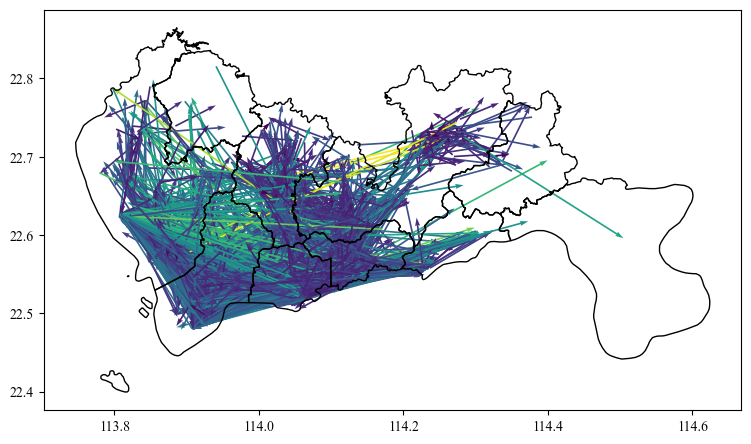

In [62]:
fdf = gfk.read_csv('./data/sz_data/sz_taxi_flow.csv', use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
mask1 = fdf['time_difference'].values > 60*30
mask2 = fdf['distance'].values > 5
fdf = fdf.loc[mask1 | mask2]
gdf = gpd.read_file('./data/sz_data/sz_border.gpkg')
ax = fdf.plot(figsize=(9, 6), column='distance')
gdf.plot(ax=ax, facecolor="none", edgecolor="black");

### Comparision of exact and barnes_hut method

In [43]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 1m21.4s, 100 iterations used 1m6s, 1.55it/s
X_embedded_exact = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

In [70]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='barnes_hut', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 21.7s, 100 iterations used 17s, 5.95it/s
X_embedded_bh = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

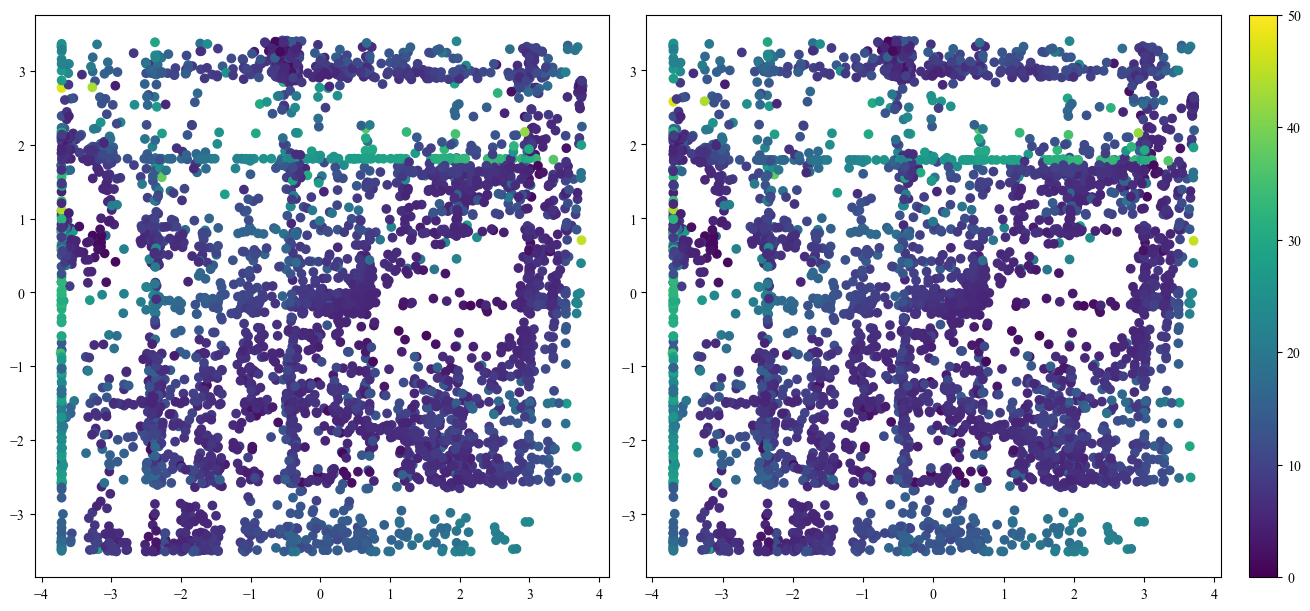

In [72]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

scatter = ax1.scatter(X_embedded_exact[:, 0], X_embedded_exact[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
scatter = ax2.scatter(X_embedded_bh[:, 0], X_embedded_bh[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);

### Comparision of local and global interpretability vis result

In [73]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='barnes_hut', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
X_embedded_local = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

In [82]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=100, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=10, verbose=1)
X_embedded_global = transformer.fit_transform(fdf.to_crs(4526), union={('o', 'd'): (0, 1)})

  0%|          | 0/100 [00:00<?, ?it/s]

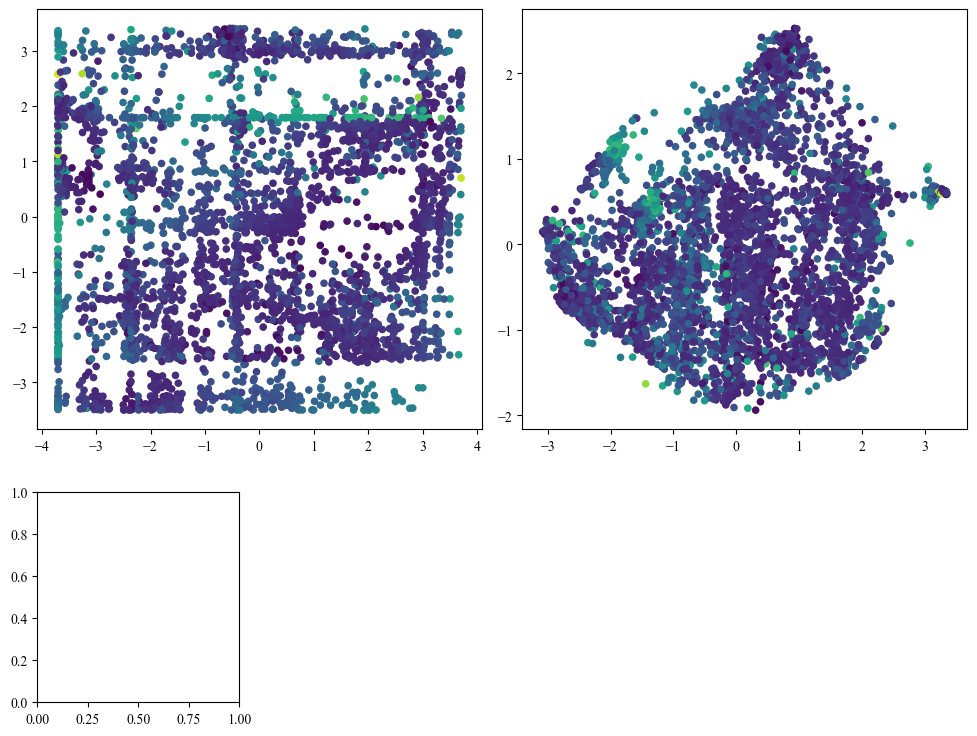

In [83]:
# 创建一个整体为 2x2 网格的画布
fig = plt.figure(figsize=(12, 9))

# 使用 GridSpec 创建一个 2x4 的网格
gs = gridspec.GridSpec(2, 4, figure=fig, height_ratios=[6, 3], width_ratios=[1, 1, 1, 1])

ax_local = fig.add_subplot(gs[:1, :2])
ax_global = fig.add_subplot(gs[:1, 2:])

scatter_exact = ax_local.scatter(X_embedded_local[:, 0], X_embedded_local[:, 1],
                                 c=fdf['distance'].values, vmin=0, vmax=50, s=20)
scatter_bh = ax_global.scatter(X_embedded_global[:, 0], X_embedded_global[:, 1], 
                               c=fdf['distance'].values, vmin=0, vmax=50, s=20)

ax_local_ex1 = fig.add_subplot(gs[1, 0])

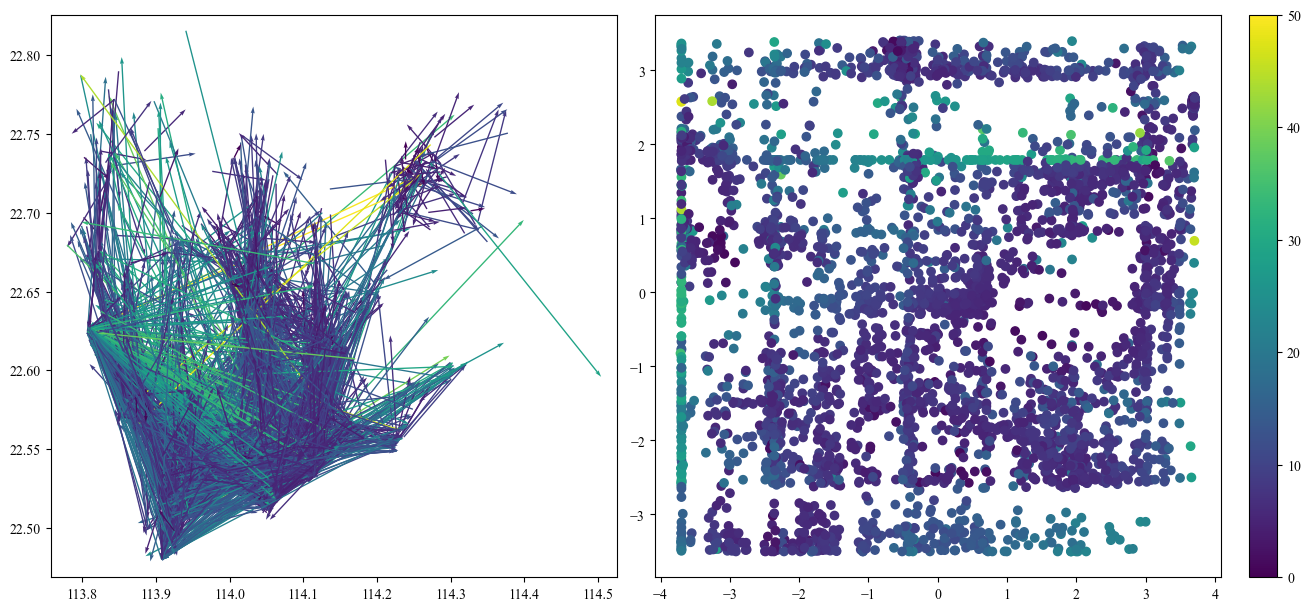

In [22]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
fdf.plot(ax=ax1, column='distance')
scatter = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);

In [23]:
transformer = FTSNE(learning_rate='auto', max_iter=100, init='pca', 
                    perplexity=300, log_progress='notebook', method='exact', 
                    early_exaggeration=12.0, early_exaggeration_iter=0, verbose=1)
# totally used 1m21.4s, 100 iterations used 1m6s, 1.55it/s
X_embedded = transformer.fit_transform(fdf.to_crs(4526), identity={'o': 0, 'd': 1})

  0%|          | 0/100 [00:00<?, ?it/s]

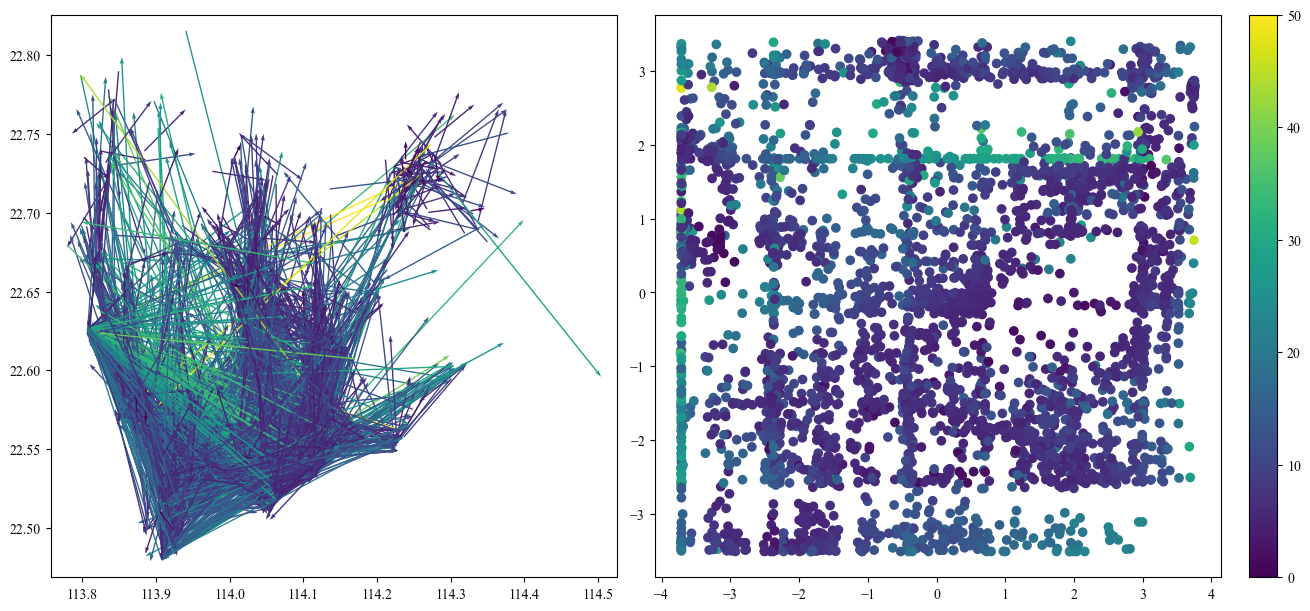

In [24]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)
fdf.plot(ax=ax1, column='distance')
scatter = ax2.scatter(X_embedded[:, 0], X_embedded[:, 1], c=fdf['distance'].values, vmin=0, vmax=50)
fig.colorbar(scatter, ax=ax2);